# Random Forest Crime Prediction Assignment

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14145456,JK191635,2026-03-19T00:00:00.000,078XX W BERWYN AVE,1150,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,OTHER (SPECIFY),False,False,...,41,10.0,11,1123120.0,1934242.0,2026,2026-03-26T15:43:32.000,41.975955,-87.822623,"\n, \n(41.975955404, -87.822623081)"
1,14141326,JK186894,2026-03-19T00:00:00.000,0000X W HUBBARD ST,2027,NARCOTICS,POSSESS - CRACK,STREET,True,False,...,42,8.0,18,1176107.0,1903313.0,2026,2026-03-26T15:43:32.000,41.890053,-87.628704,"\n, \n(41.890053025, -87.628704402)"
2,14141351,JK186867,2026-03-19T00:00:00.000,007XX S MICHIGAN AVE,0810,THEFT,OVER $500,HOTEL / MOTEL,False,False,...,4,32.0,06,1177389.0,1897003.0,2026,2026-03-26T15:43:32.000,41.872709,-87.624188,"\n, \n(41.872709056, -87.624187857)"
3,14142106,JK187663,2026-03-19T00:00:00.000,007XX E 47TH ST,0560,ASSAULT,SIMPLE,STREET,False,False,...,4,38.0,08A,1182174.0,1874015.0,2026,2026-03-26T15:43:32.000,41.809519,-87.607334,"\n, \n(41.809518699, -87.607333603)"
4,14140758,JK186030,2026-03-19T00:00:00.000,006XX N CENTRAL AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,ALLEY,False,True,...,29,25.0,14,1138919.0,1903598.0,2026,2026-03-26T15:43:32.000,41.891592,-87.765270,"\n, \n(41.891591889, -87.765269754)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent?
>Each row is a single crime occurence
2. Which variables look potentially useful for prediction?
>Primary type, description, location description, domestic, district, latitude/longitude
3. Which variable appears to be the target for this assignment?
>Arrest


In [ ]:
df.info()

In [ ]:
df.describe(include='all')

## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [3]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,DECEPTIVE PRACTICE,False,False,16,41.975955,-87.822623
1,NARCOTICS,True,False,18,41.890053,-87.628704
2,THEFT,False,False,1,41.872709,-87.624188
3,ASSAULT,False,False,2,41.809519,-87.607334
4,CRIMINAL DAMAGE,False,True,15,41.891592,-87.765270


### Short Response
Why might missing values cause problems in machine learning and mapping?
>Missing values can cause several issues:
- Many machine learning models cannot handle NaN values directly
- Missing latitude or longitude would cause mapping tools like Folium to fail or place markers incorrectly
- Missing data can introduce bias if certain types of crimes or districts are underrepresented after cleaning
- It can reduce model accuracy because incomplete patterns weaken learning

## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [4]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas?
> Crime points tend to cluster in certain areas, especially in dense urban neighborhoods. They are not evenly distributed across the city
2. Do you see any visible differences between arrest and non-arrest locations?
> The crime goes everywhere of the points we see, but it seems like there's a little more crime towards the center of Chicago on the map than anywhere else
3. If location turns out to be important later, does this map help explain why?
> Yes. If latitude/longitude or district becomes highly important in feature importance, this clustering helps explain why. Certain areas may have stronger enforcement presence or different crime patterns

## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


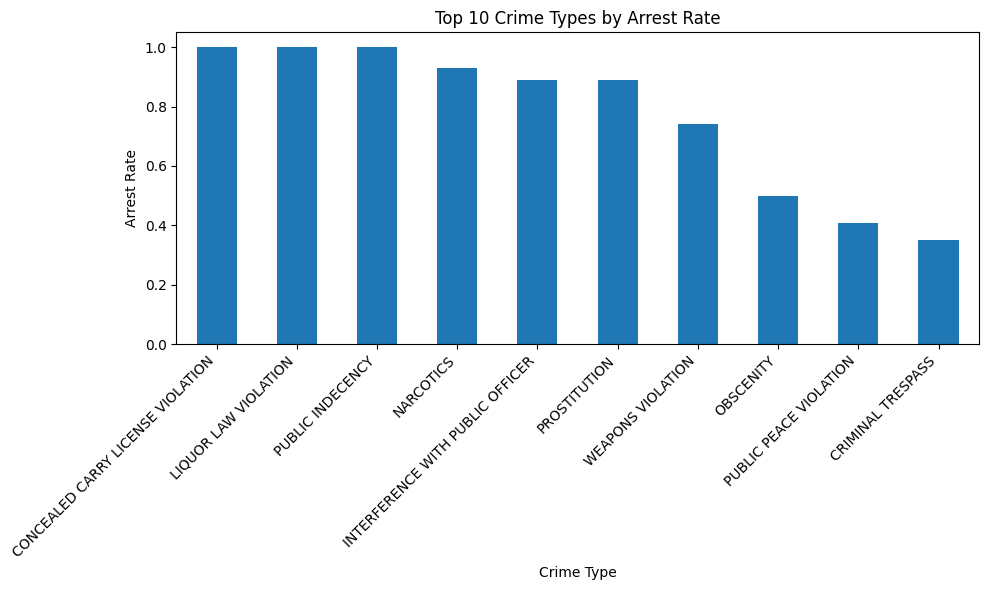

In [5]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
Which crime types seem most likely to lead to arrest? Does this surprise you?
>Concealed carry license violation, liquor law violation, and public indecency. The public indecency and concealed carry doesn't surprise me, but I didn't think liquor would be that high

## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [6]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,False,41.975955,-87.822623,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,True,False,41.890053,-87.628704,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,41.872709,-87.624188,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,41.809519,-87.607334,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,41.891592,-87.765270,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [7]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8662394873848618

Confusion Matrix:
[[7898  454]
 [ 882  754]]

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.95      0.92      8352
        True       0.62      0.46      0.53      1636

    accuracy                           0.87      9988
   macro avg       0.76      0.70      0.73      9988
weighted avg       0.85      0.87      0.86      9988



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.323720
longitude,0.322333
primary_type_NARCOTICS,0.149995
primary_type_WEAPONS VIOLATION,0.055017
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.020823
domestic,0.011113
primary_type_CRIMINAL DAMAGE,0.010011
primary_type_CRIMINAL TRESPASS,0.009809
primary_type_MOTOR VEHICLE THEFT,0.008162
primary_type_BATTERY,0.007439


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


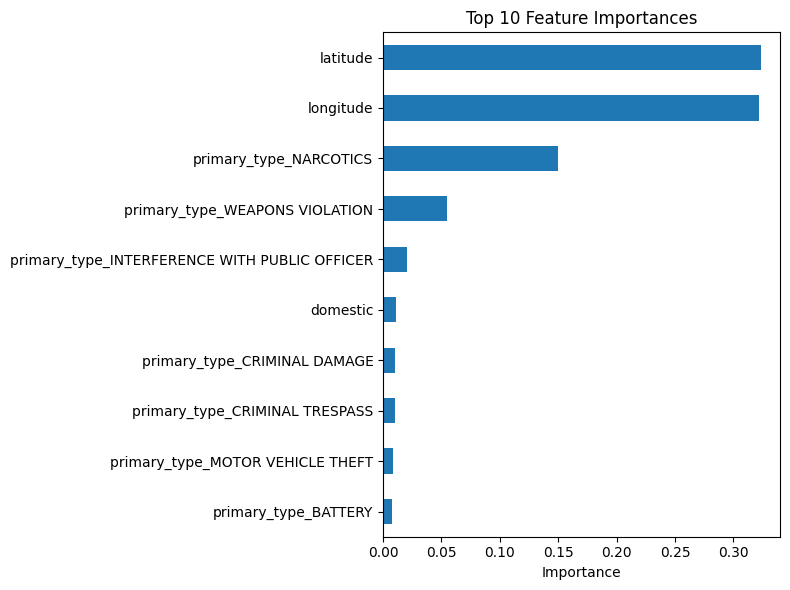

In [12]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most?
> It seems that latitude and longitude are the most important
2. Does the model seem to rely more on **location** or **crime type**?
> The model appears to rely strongly on location because latitude and longitude are the two most important individual features. However, several crime-type variables also rank highly, suggesting that both location and crime type significantly influence arrest outcomes. While location has the strongest individual impact, crime type collectively plays a substantial role
3. What does that suggest about arrest outcomes in the dataset?
> This suggests that arrest outcomes vary significantly by location


## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86944333 0.86832883 0.87263442 0.87413638 0.86202063]
Average cross-validation score: 0.8693127176663262


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well?
> The model does a good job identifying patterns in the data that are associated with whether an arrest was made. It handles a large number of features effectively and is able to capture complex relationships between crime type, location, and arrest outcomes. The cross-validation results suggest that the model performs consistently across different subsets of the data, which increases confidence that it is not just memorizing the training set
2. What are its limitations?
> One major limitation is that the model only learns from historical data. If there are existing policing biases or uneven enforcement patterns in certain neighborhoods, the model will reflect those patterns. It also cannot account for context, such as officer discretion, witness cooperation, or situational details that may influence whether an arrest occurs. Additionally, accuracy alone does not measure fairness, and the model may perform differently across different districts or communities
3. What does feature importance suggest about the strongest predictors of arrest?
> Feature importance shows that latitude and longitude are the most influential individual variables. This suggests that location plays a major role in whether an arrest is made. Several crime type variables also rank highly, indicating that the nature of the offense matters as well. Overall, the model suggests that arrest outcomes are strongly shaped by both geography and crime category
4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself?
> It is important because the model is not predicting whether someone will commit a crime. It is only learning patterns about police response after a crime has already occurred. Arrest outcomes depend on law enforcement practices, reporting behavior, and enforcement strategies. Confusing arrest prediction with crime prediction could lead to incorrect or harmful interpretations
5. Should a model like this be used in real-world policing decisions? Why or why not?
> A model like this should be used with extreme caution. While it can help identify patterns and provide insight into how arrest outcomes vary by location and crime type, it should not be used as the sole basis for policing decisions. Because it reflects historical data, it could reinforce existing inequalities or over policing in certain areas. Any real world use would require transparency, fairness testing, and strong human oversight